In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df = pd.read_csv(r"C:\Users\ADITYA GUPTA\Downloads\Data\Apple_North_India_FY23_24_Sales.csv")

# Data Cleaning

In [40]:
df.head(3)

,Transaction_ID,Date,City_Cluster,POS_ID (Store-Terminal),Product_Category,Product_Name,MRP,Trade_In_Taken,Trade_In_Credit,Bank_Cashback,Net_Revenue,Accessory_Revenue,Payment_Type,Customer_Age,Customer_Profession,Main_Accessory_Sold
0,TRX_0000001,4/6/2023,Rishikesh,RISHIKESH_04,Mac,MacBook Air M2 (8/256),114900,False,0,0,119410,4510,Credit Card,30,Tech Entrepreneur,AppleCare+
1,TRX_0000002,4/6/2023,Rishikesh,RISHIKESH_06,iPhone (Old),iPhone 13 (128GB),69900,False,0,0,71680,1780,Debit Card,23,Marketing Exec,Case/Cover (Premium)
2,TRX_0000003,4/6/2023,Rishikesh,RISHIKESH_03,Audio,AirPods Pro 2,24900,False,0,7000,19130,1230,UPI/Cash,28,Retail/Service,AppleCare+


In [41]:
df.shape

(300000, 16)

In [42]:
df.isnull().sum()

Transaction_ID                 0
Date                           0
City_Cluster                   0
POS_ID (Store-Terminal)        0
Product_Category               0
Product_Name                   0
MRP                            0
Trade_In_Taken                 0
Trade_In_Credit                0
Bank_Cashback                  0
Net_Revenue                    0
Accessory_Revenue              0
Payment_Type                   0
Customer_Age                   0
Customer_Profession            0
Main_Accessory_Sold        14854
dtype: int64

In [43]:
df = df.dropna()

In [44]:
df.isnull().sum()

Transaction_ID             0
Date                       0
City_Cluster               0
POS_ID (Store-Terminal)    0
Product_Category           0
Product_Name               0
MRP                        0
Trade_In_Taken             0
Trade_In_Credit            0
Bank_Cashback              0
Net_Revenue                0
Accessory_Revenue          0
Payment_Type               0
Customer_Age               0
Customer_Profession        0
Main_Accessory_Sold        0
dtype: int64

In [45]:
df['Transaction_ID'].duplicated().sum()

np.int64(0)

In [46]:
df.describe()

,MRP,Trade_In_Credit,Bank_Cashback,Net_Revenue,Accessory_Revenue,Customer_Age
count,285146.000000,285146.000000,285146.000000,285146.000000,285146.000000,285146.000000
mean,87275.961788,4901.075940,3587.271082,81405.782652,2618.167886,28.886507
std,38543.074739,10148.168815,3943.492016,39034.891346,1597.600956,6.070568
min,24900.000000,0.000000,0.000000,6600.000000,250.000000,16.000000
25%,69900.000000,0.000000,0.000000,60540.000000,1440.000000,25.000000
50%,79900.000000,0.000000,0.000000,72790.000000,2330.000000,29.000000
75%,114900.000000,0.000000,7000.000000,83780.000000,3330.000000,33.000000
max,199900.000000,70000.000000,10000.000000,209890.000000,9990.000000,45.000000


In [47]:
df.head(2)

,Transaction_ID,Date,City_Cluster,POS_ID (Store-Terminal),Product_Category,Product_Name,MRP,Trade_In_Taken,Trade_In_Credit,Bank_Cashback,Net_Revenue,Accessory_Revenue,Payment_Type,Customer_Age,Customer_Profession,Main_Accessory_Sold
0,TRX_0000001,4/6/2023,Rishikesh,RISHIKESH_04,Mac,MacBook Air M2 (8/256),114900,False,0,0,119410,4510,Credit Card,30,Tech Entrepreneur,AppleCare+
1,TRX_0000002,4/6/2023,Rishikesh,RISHIKESH_06,iPhone (Old),iPhone 13 (128GB),69900,False,0,0,71680,1780,Debit Card,23,Marketing Exec,Case/Cover (Premium)


In [48]:
df.dtypes

Transaction_ID               str
Date                         str
City_Cluster                 str
POS_ID (Store-Terminal)      str
Product_Category             str
Product_Name                 str
MRP                        int64
Trade_In_Taken              bool
Trade_In_Credit            int64
Bank_Cashback              int64
Net_Revenue                int64
Accessory_Revenue          int64
Payment_Type                 str
Customer_Age               int64
Customer_Profession          str
Main_Accessory_Sold          str
dtype: object

In [49]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

In [50]:
df.head(3)

,Transaction_ID,Date,City_Cluster,POS_ID (Store-Terminal),Product_Category,Product_Name,MRP,Trade_In_Taken,Trade_In_Credit,Bank_Cashback,Net_Revenue,Accessory_Revenue,Payment_Type,Customer_Age,Customer_Profession,Main_Accessory_Sold
0,TRX_0000001,2023-06-04,Rishikesh,RISHIKESH_04,Mac,MacBook Air M2 (8/256),114900,False,0,0,119410,4510,Credit Card,30,Tech Entrepreneur,AppleCare+
1,TRX_0000002,2023-06-04,Rishikesh,RISHIKESH_06,iPhone (Old),iPhone 13 (128GB),69900,False,0,0,71680,1780,Debit Card,23,Marketing Exec,Case/Cover (Premium)
2,TRX_0000003,2023-06-04,Rishikesh,RISHIKESH_03,Audio,AirPods Pro 2,24900,False,0,7000,19130,1230,UPI/Cash,28,Retail/Service,AppleCare+


In [51]:
df['Product_Category'].value_counts()

Product_Category
iPhone          96787
iPhone (Old)    63937
iPhone (Pro)    41649
Mac             21723
iPad            19417
Audio           19389
Watch           13946
Mac (Pro)        8298
Name: count, dtype: int64

# FEATURE ENGINEERING

In [52]:
df.head(3)

,Transaction_ID,Date,City_Cluster,POS_ID (Store-Terminal),Product_Category,Product_Name,MRP,Trade_In_Taken,Trade_In_Credit,Bank_Cashback,Net_Revenue,Accessory_Revenue,Payment_Type,Customer_Age,Customer_Profession,Main_Accessory_Sold
0,TRX_0000001,2023-06-04,Rishikesh,RISHIKESH_04,Mac,MacBook Air M2 (8/256),114900,False,0,0,119410,4510,Credit Card,30,Tech Entrepreneur,AppleCare+
1,TRX_0000002,2023-06-04,Rishikesh,RISHIKESH_06,iPhone (Old),iPhone 13 (128GB),69900,False,0,0,71680,1780,Debit Card,23,Marketing Exec,Case/Cover (Premium)
2,TRX_0000003,2023-06-04,Rishikesh,RISHIKESH_03,Audio,AirPods Pro 2,24900,False,0,7000,19130,1230,UPI/Cash,28,Retail/Service,AppleCare+


In [53]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [54]:
bins = [15, 19, 35, 55, 70]
labels = ['Teen', 'Young Adult', 'Adult', 'Senior']

df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels, right=False)

# KPI ANALYSIS

In [55]:
df.head(2)

,Transaction_ID,Date,City_Cluster,POS_ID (Store-Terminal),Product_Category,Product_Name,MRP,Trade_In_Taken,Trade_In_Credit,Bank_Cashback,Net_Revenue,Accessory_Revenue,Payment_Type,Customer_Age,Customer_Profession,Main_Accessory_Sold,Month,Year,Age_Group
0,TRX_0000001,2023-06-04,Rishikesh,RISHIKESH_04,Mac,MacBook Air M2 (8/256),114900,False,0,0,119410,4510,Credit Card,30,Tech Entrepreneur,AppleCare+,6,2023,Young Adult
1,TRX_0000002,2023-06-04,Rishikesh,RISHIKESH_06,iPhone (Old),iPhone 13 (128GB),69900,False,0,0,71680,1780,Debit Card,23,Marketing Exec,Case/Cover (Premium),6,2023,Young Adult


In [56]:
# Total Revenue
df['Net_Revenue'].sum()

np.int64(23212533300)

In [57]:
# Total Orders
df['Transaction_ID'].nunique()

285146

In [58]:
# Average Order Value
df['Net_Revenue'].mean()

np.float64(81405.78265169422)

In [59]:
df['Accessory_Revenue'].sum()

np.int64(746560100)

# VISUALIZATIONS

In [60]:
df.head(4)

,Transaction_ID,Date,City_Cluster,POS_ID (Store-Terminal),Product_Category,Product_Name,MRP,Trade_In_Taken,Trade_In_Credit,Bank_Cashback,Net_Revenue,Accessory_Revenue,Payment_Type,Customer_Age,Customer_Profession,Main_Accessory_Sold,Month,Year,Age_Group
0,TRX_0000001,2023-06-04,Rishikesh,RISHIKESH_04,Mac,MacBook Air M2 (8/256),114900,False,0,0,119410,4510,Credit Card,30,Tech Entrepreneur,AppleCare+,6,2023,Young Adult
1,TRX_0000002,2023-06-04,Rishikesh,RISHIKESH_06,iPhone (Old),iPhone 13 (128GB),69900,False,0,0,71680,1780,Debit Card,23,Marketing Exec,Case/Cover (Premium),6,2023,Young Adult
2,TRX_0000003,2023-06-04,Rishikesh,RISHIKESH_03,Audio,AirPods Pro 2,24900,False,0,7000,19130,1230,UPI/Cash,28,Retail/Service,AppleCare+,6,2023,Young Adult
3,TRX_0000004,2023-06-04,Rishikesh,RISHIKESH_06,iPhone (Pro),iPhone 14 Pro Max (256GB),149900,False,0,5000,149660,4760,EMI/Card,31,High-Tier Student,Screen Protector,6,2023,Young Adult


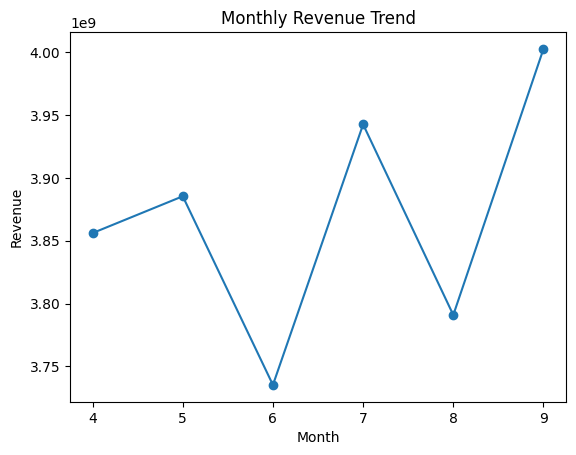

In [61]:
# Monthly Revenue Trend
monthly_sales = df.groupby('Month')['Net_Revenue'].sum()

monthly_sales.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

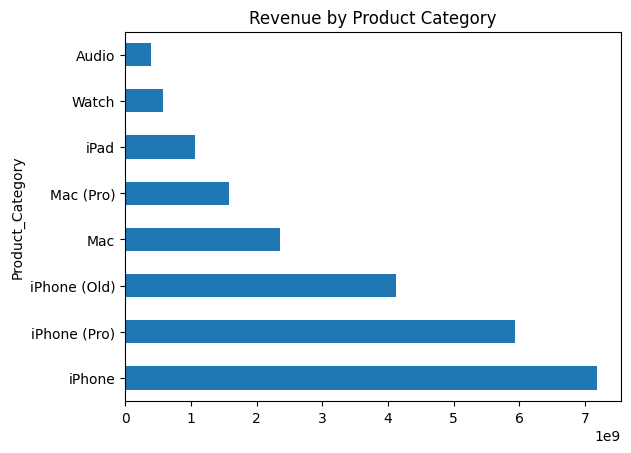

In [62]:
# Revenue by Payment Category
cat_sales = df.groupby('Product_Category')['Net_Revenue'].sum().sort_values(ascending=False)

cat_sales.plot(kind='barh')
plt.title("Revenue by Product Category")
plt.show()

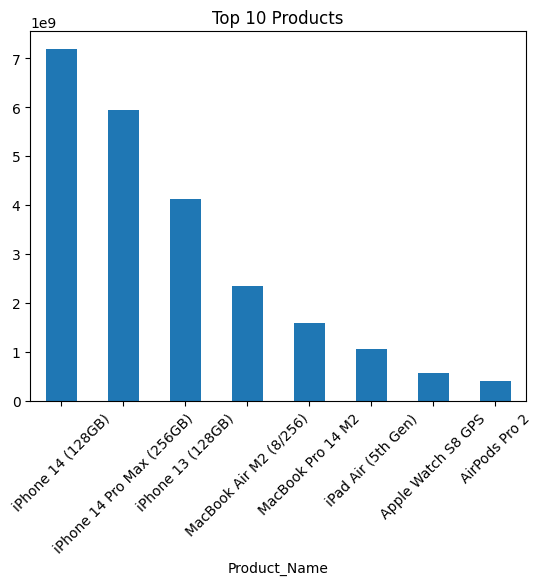

In [63]:
#top 10 products by revenue
top_products = df.groupby('Product_Name')['Net_Revenue'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.xticks(rotation=45)
plt.show()

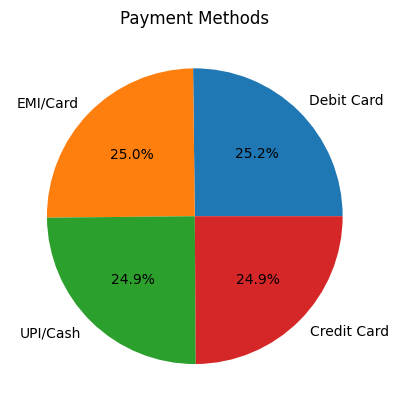

In [64]:
#Payment Methods Distribution
df['Payment_Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Payment Methods")
plt.show()

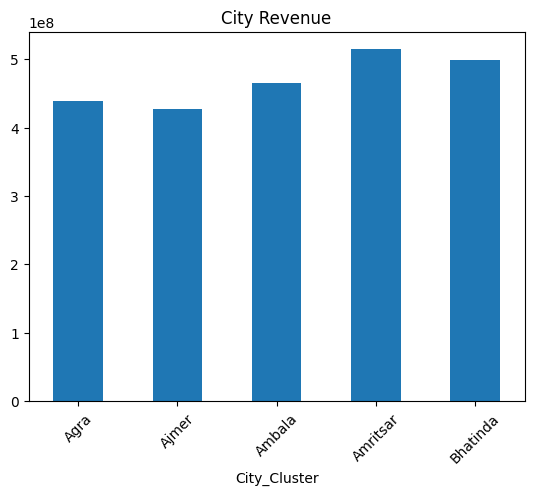

In [65]:
#city wise revenue
city_rev = df.groupby('City_Cluster')['Net_Revenue'].sum().head(5)

city_rev.plot(kind='bar')
plt.title("City Revenue")
plt.xticks(rotation=45)
plt.show()

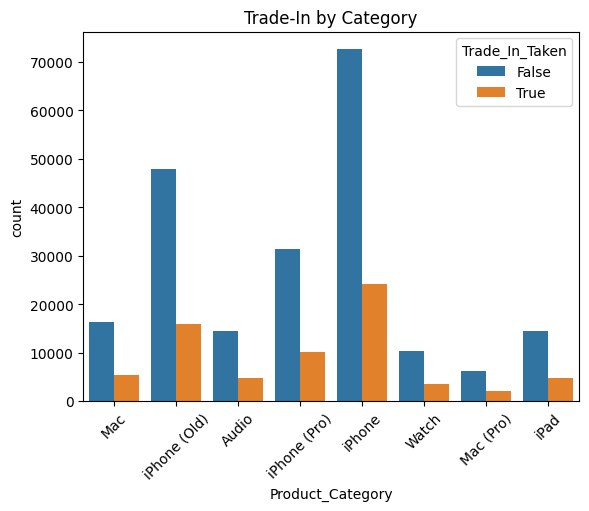

In [66]:
# Trade-In by Category
sns.countplot(
    data=df,
    x='Product_Category',
    hue='Trade_In_Taken'
)

plt.title("Trade-In by Category")
plt.xticks(rotation=45)
plt.show()

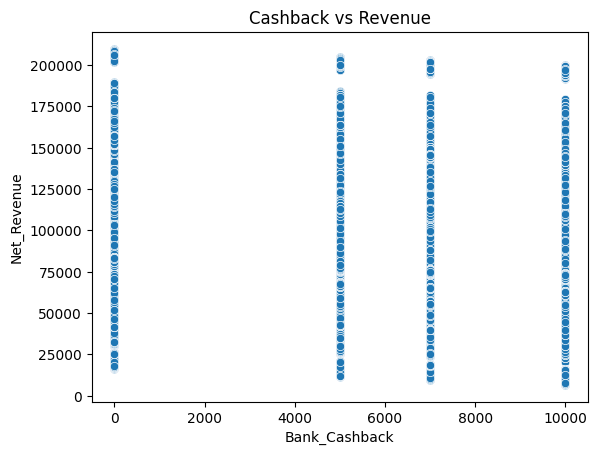

In [67]:
# Cashback vs Revenue
sns.scatterplot(
    data=df,
    x='Bank_Cashback',
    y='Net_Revenue'
)

plt.title("Cashback vs Revenue")
plt.show()

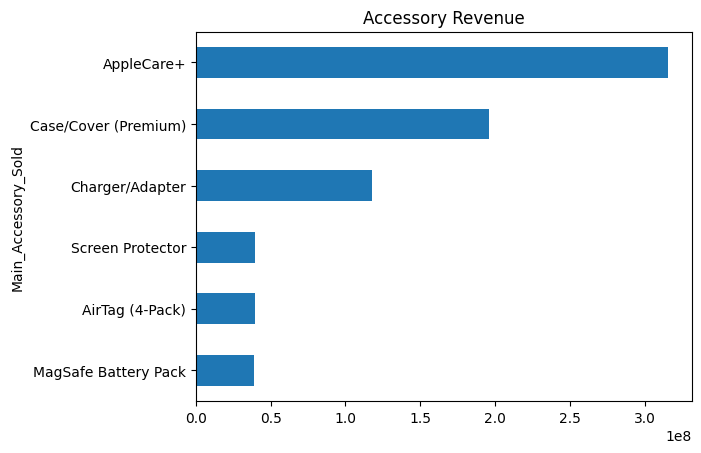

In [68]:
# Accessory Revenue by Main Accessory Sold
acc = df.groupby('Main_Accessory_Sold')['Accessory_Revenue'].sum().sort_values()

acc.plot(kind='barh')
plt.title("Accessory Revenue")
plt.show()

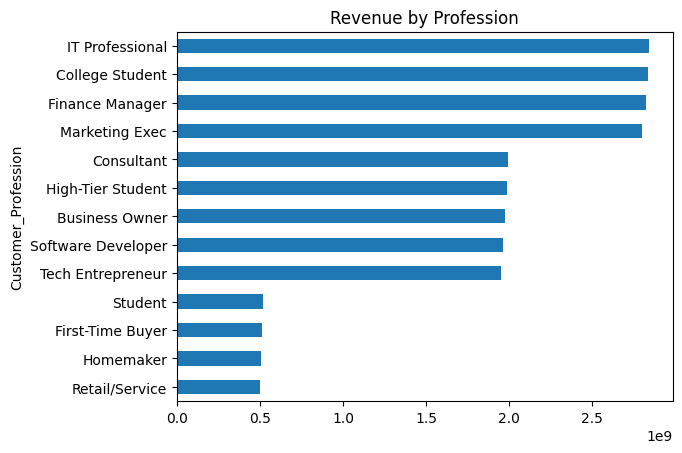

In [69]:
# Revenue by Profession
prof = df.groupby('Customer_Profession')['Net_Revenue'].sum().sort_values()

prof.plot(kind='barh')
plt.title("Revenue by Profession")
plt.show()

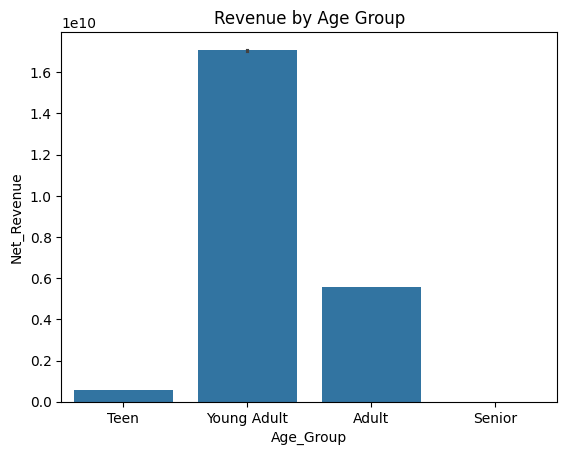

In [70]:
# Revenue by Age Group
sns.barplot(
    data=df,
    x='Age_Group',
    y='Net_Revenue',
    estimator=sum
)

plt.title("Revenue by Age Group")
plt.show()

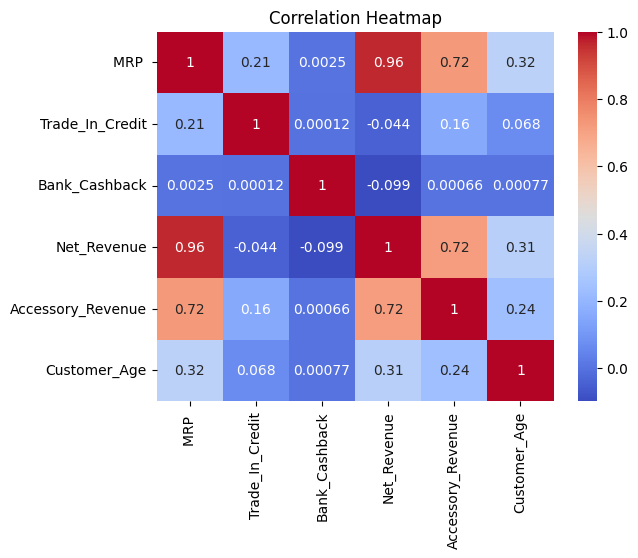

In [71]:
# Correlation Heatmap
numeric_cols = [
    'MRP ',
    'Trade_In_Credit',
    'Bank_Cashback',
    'Net_Revenue',
    'Accessory_Revenue',
    'Customer_Age'
]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [72]:
apple_df = df[df['Product_Name'].str.contains('Apple', case=False, na=False)]

city_apple_sales = apple_df.groupby('City_Cluster')['Net_Revenue'].sum().sort_values(ascending=False).head(5)